<a id="kalshi-market-time-series-construction"></a>
# Kalshi Market Time Series Construction
Process all markets & trades parquet files to build bid-ask spread and last price time series.

## Table of contents

1. [Milestone 2 - EDA](#kalshi-market-time-series-construction)
2. [Milestone 3 — Baseline Model](#milestone-eda-features)


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fastparquet


REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
PATH = REPO_ROOT / "data" / "kalshi"
MARKETS_DIR = PATH / "markets"
TRADES_DIR = PATH / "trades"
OUTPUT_DIR = PATH / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

market_files = sorted(MARKETS_DIR.glob("*.parquet"))
trade_files = sorted(TRADES_DIR.glob("*.parquet"))
print(f"Market files: {len(market_files)}, Trade files: {len(trade_files)}")

Market files: 769, Trade files: 7214


## Process Markets — extract bid/ask/spread/last_price per ticker over time
We process in chunks to avoid OOM, keeping only the columns we need.

In [ ]:
MARKET_COLS = ["ticker", "yes_bid", "yes_ask", "no_bid", "no_ask", "last_price", "open_time", "close_time", "status", "volume"]

chunks = []
for i, f in enumerate(market_files):
    trade_ts = pd.read_parquet(f, columns=MARKET_COLS)
    chunks.append(trade_ts)
    if (i + 1) % 100 == 0:
        print(f"  loaded {i+1}/{len(market_files)} market files")

markets = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Total market rows: {len(markets):,}")
markets.head()

  loaded 100/769 market files
  loaded 200/769 market files
  loaded 300/769 market files
  loaded 400/769 market files
  loaded 500/769 market files
  loaded 600/769 market files
  loaded 700/769 market files
Total market rows: 7,682,445


,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0


In [ ]:
# Compute spreads
markets["yes_spread"] = markets["yes_ask"] - markets["yes_bid"]
markets["no_spread"] = markets["no_ask"] - markets["no_bid"]

# Parse times
markets["open_time"] = pd.to_datetime(markets["open_time"], utc=True)
markets["close_time"] = pd.to_datetime(markets["close_time"], utc=True)

markets.head()

,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume,yes_spread,no_spread
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0,0,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0,0,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0,0,0


In [ ]:
# Save full processed markets table
markets.to_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"), index=False)
print("Saved all_markets.parquet")

Saved all_markets.parquet


# Check that yes and no prices are consistent

In [ ]:
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

trades.head()


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [ ]:
trades["arb"] = (trades["yes_price"] + trades["no_price"] != 100).astype(int)
count_arb = trades["arb"].sum()/len(trades)*100
print(f"Number of arbitrage trades: {count_arb}")


arb_df = trades[trades["arb"] == 1]

arb_df.head()

Number of arbitrage trades: 0.3705440628115654


,ticker,yes_price,no_price,count,taker_side,created_time,arb
43563860,KXMVENFLSINGLEGAME-20254463FD1612A-16371CBD9FC,0,99,200,yes,2025-10-09 15:28:03.087254+00:00,1
43564049,KXMVENFLSINGLEGAME-2025BD87D5E46B5-91E6C41D5DE,3,96,249,yes,2025-10-09 15:28:49.067634+00:00,1
43564138,KXMVENFLSINGLEGAME-2025BD87D5E46B5-C3458DB16DF,2,97,446,yes,2025-10-09 15:29:16.099825+00:00,1
43564410,KXMVENFLSINGLEGAME-2025BD87D5E46B5-2CEEF6F8468,1,98,456,yes,2025-10-09 15:30:33.070604+00:00,1
43564670,KXMVENFLSINGLEGAME-202585F482F88EE-5CE6BD56FDD,4,95,20,yes,2025-10-09 15:31:28.075791+00:00,1


In [ ]:
arb_df["arb_amount"] = 100 - (arb_df["yes_price"] + arb_df["no_price"])
arb_df["arb_amount"].describe()

C:\Users\ablan\AppData\Local\Temp\ipykernel_11020\2205500781.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  arb_df["arb_amount"] = 100 - (arb_df["yes_price"] + arb_df["no_price"])


count    267291.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: arb_amount, dtype: float64

Given that all the inconsistencies are 1.0, its probably due to rounding errors; Note that the actual Kalshi prices can be decimal points when nearing ends

- so can remove no price as it is a linear combination of yes price

In [ ]:
# remove no_price from trades to save space
trades.drop(columns=["no_price"], inplace=True)
trades.head()

,ticker,yes_price,count,taker_side,created_time,arb
0,HOME-21JUN-T750,76,5,yes,2021-06-30 20:09:14.185137+00:00,0
1,HOME-21JUN-T750,76,10,yes,2021-07-01 14:53:12.675773+00:00,0
2,CPI-21JUN-T0.6,17,100,yes,2021-07-01 14:53:38.613666+00:00,0
3,GDP-21JUN30-T6.0,81,20,yes,2021-07-01 14:54:00.422415+00:00,0
4,TRDDEFCN-21MAY-T30,34,100,yes,2021-07-01 14:54:11.235167+00:00,0


# Quick summary stats & sanity checks

In [ ]:
# Load processed data
markets = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"))
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

trades.head()


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [ ]:
print("\n=== Trades ===")
print(f"Unique tickers traded: {trades['ticker'].nunique():,}")
print(f"Date range: {trades['created_time'].min()} -> {trades['created_time'].max()}")
print(f"Total number of trades: {len(trades):,}")
print(f"Yes price stats:")
print(trades["yes_price"].describe())


=== Trades ===
Unique tickers traded: 586,025
Date range: 2021-06-30 20:09:14.185137+00:00 -> 2025-11-25 22:00:15.194245+00:00
Total number of trades: 72,134,741
Yes price stats:
count    7.213474e+07
mean     4.400762e+01
std      2.779086e+01
min      0.000000e+00
25%      2.000000e+01
50%      4.300000e+01
75%      6.500000e+01
max      9.900000e+01
Name: yes_price, dtype: float64


Most traded ticker: PRES-2024-DJT


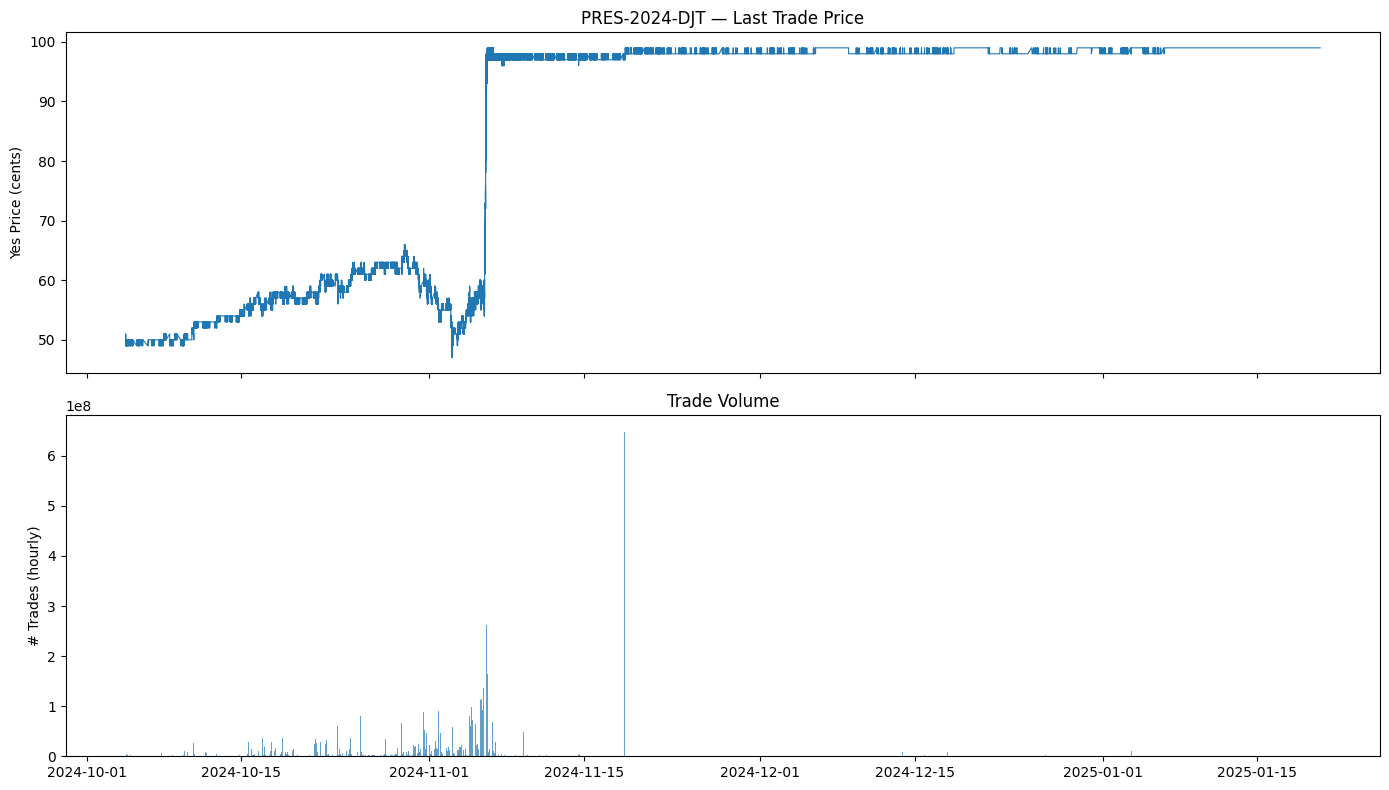

In [ ]:
top_ticker = trades.groupby("ticker").size().idxmax()
print(f"Most traded ticker: {top_ticker}")

ts = trades[trades["ticker"] == top_ticker].set_index("created_time").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts["yes_price"], lw=0.8)
axes[0].set_ylabel("Yes Price (cents)")
axes[0].set_title(f"{top_ticker} — Last Trade Price")

# Resample volume to hourly so bar chart has far fewer bars
volume = np.where(ts["taker_side"] == "yes",
                  ts["count"] * ts["yes_price"],
                  ts["count"] * ts["no_price"])

volume = pd.Series(volume, index=ts.index).resample("1h").sum()

axes[1].bar(volume.index, volume.values, width=0.03, alpha=0.7)
axes[1].set_ylabel("# Trades (hourly)")
axes[1].set_title("Trade Volume")

plt.tight_layout()
plt.show()



In [ ]:
# add volume as a feature
trades["volume"] = np.where(trades["taker_side"] == "yes",
                            trades["count"] * trades["yes_price"],
                            trades["count"] * (100-trades["yes_price"]))/100 # convert to dollars
trades.head()

,ticker,yes_price,no_price,count,taker_side,created_time,volume
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00,3.8
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00,7.6
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00,17.0
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00,16.2
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00,34.0


### Liquidity metrics

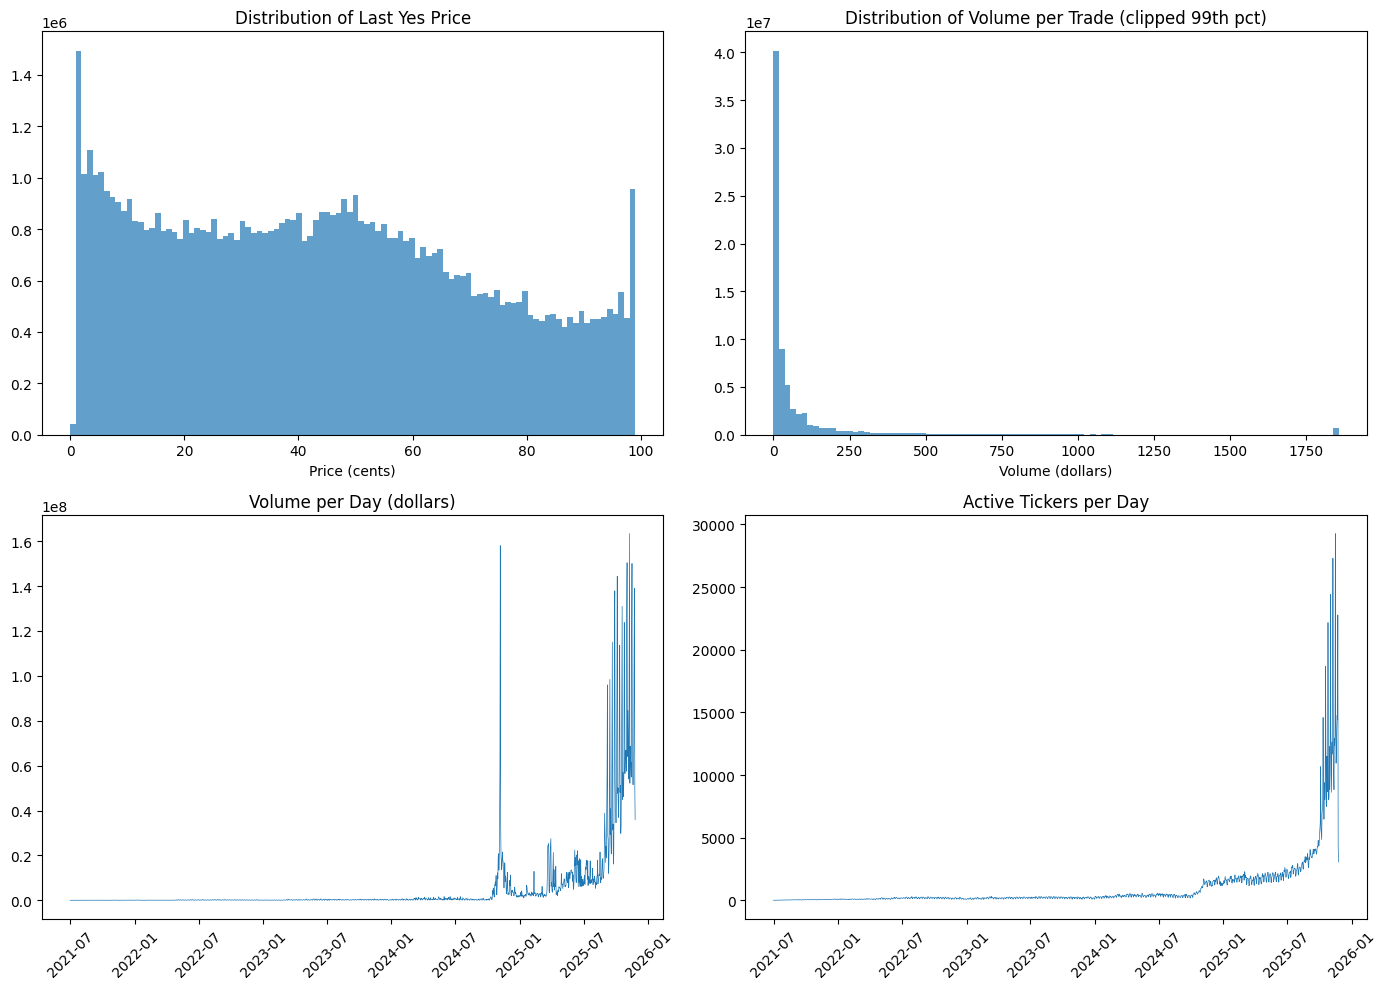

In [ ]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Filtering poor contracts
### Do not want poor data from illiquid contracts
- At first wanted to filter by number of a contract
    - However this introduces lookahead bias
- Decided to cut by timestamp, since Kalshi was not heavily used before a certain point


In [ ]:
# Find the first day with > 10M daily volume
daily_volume = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
first_10m = daily_volume[daily_volume > 10000000].index[0]
print(f"First day with > 10M volume: {first_10m}")
original_rows = len(trades)
# Fix: convert date -> UTC-aware Timestamp for comparison
first_10m_ts = pd.Timestamp(first_10m, tz='UTC')


# Remove all trades before this date as well
original_rows = len(trades)
trades = trades[trades["created_time"] >= first_10m_ts].reset_index(drop=True)
print(f"Rows after removing early trades: {original_rows:,} -> {len(trades):,} rows")

First day with > 10M volume: 2024-10-25
Rows after removing early trades: 72,134,741 -> 67,733,505 rows


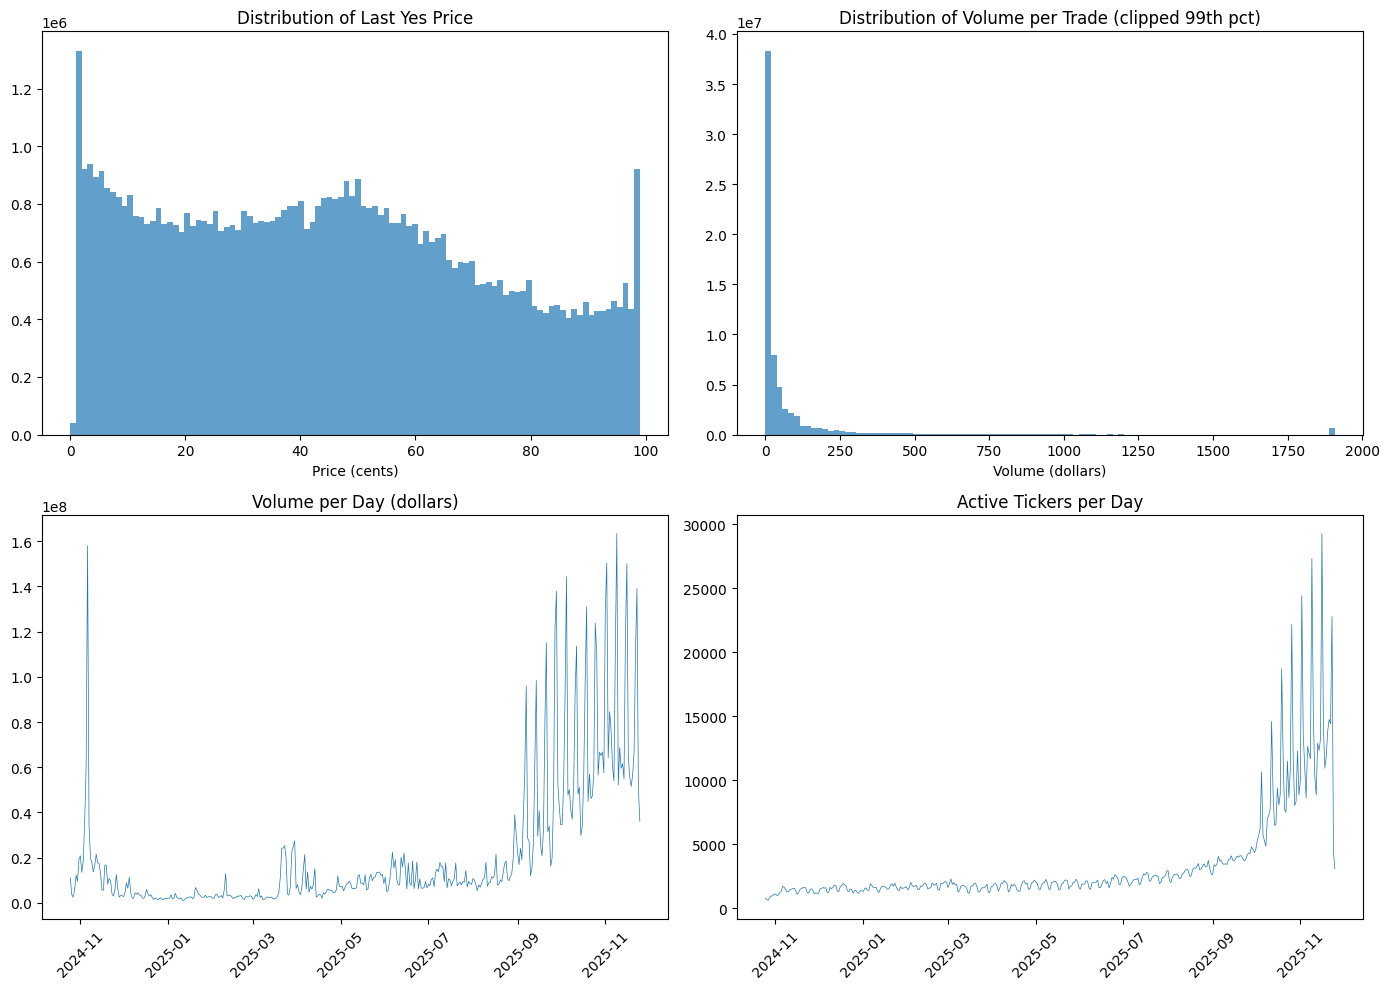

In [ ]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Misc

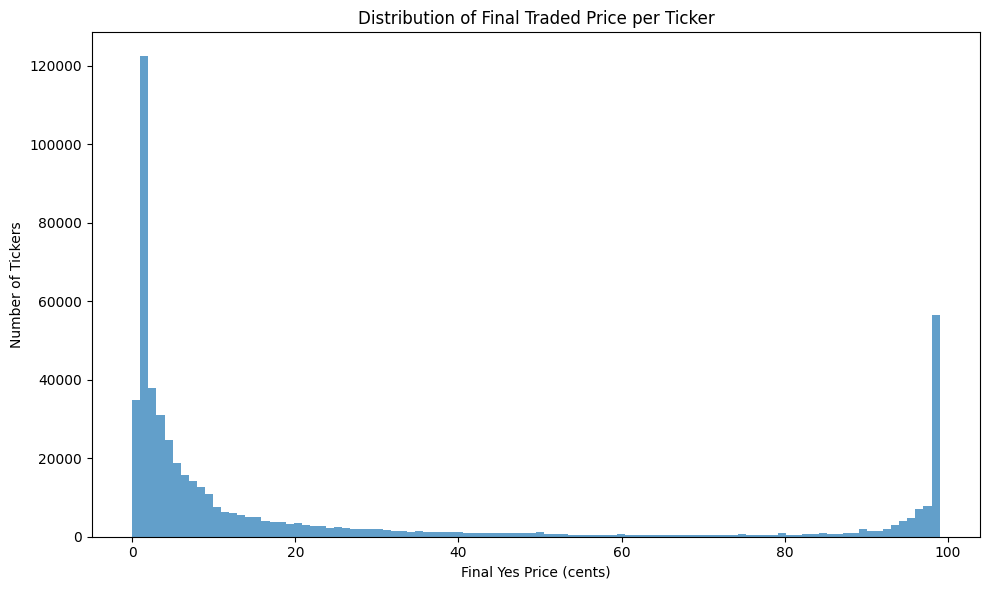

count    533794.000000
mean         25.184732
std          36.228752
min           0.000000
25%           1.000000
50%           5.000000
75%          31.000000
max          99.000000
Name: yes_price, dtype: float64

Tickers ending 0-5 cents:   269,628
Tickers ending 95-100 cents: 80,261
Tickers in between:          183,905


In [ ]:
last_price_per_ticker = (
    trades.sort_values("created_time")
            .groupby("ticker")[("yes_price")]
            .last()
)

plt.figure(figsize=(10, 6))
plt.hist(last_price_per_ticker, bins=100, edgecolor="none", alpha=0.7)
plt.title("Distribution of Final Traded Price per Ticker")
plt.xlabel("Final Yes Price (cents)")
plt.ylabel("Number of Tickers")
plt.tight_layout()
plt.show()

print(last_price_per_ticker.describe())
print(f"\nTickers ending 0-5 cents:   {(last_price_per_ticker <= 5).sum():,}")
print(f"Tickers ending 95-100 cents: {(last_price_per_ticker >= 95).sum():,}")
print(f"Tickers in between:          {((last_price_per_ticker > 5) & (last_price_per_ticker < 95)).sum():,}")

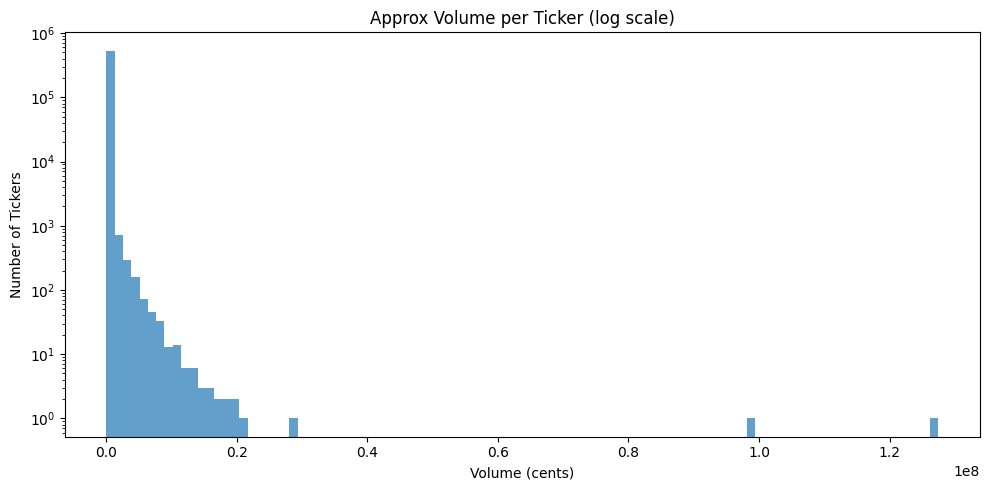

count    5.337940e+05
mean     1.551193e+04
std      3.116735e+05
min      0.000000e+00
25%      1.111000e+01
50%      1.122400e+02
75%      1.398697e+03
max      1.274906e+08
Name: volume, dtype: float64


In [ ]:
vol_per_ticker = trades.groupby("ticker")["volume"].sum()

fig, ax = plt.subplots(figsize=(10, 5))  # just 1 subplot

ax.hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7, log=True)
ax.set_title("Approx Volume per Ticker (log scale)")
ax.set_xlabel("Volume (cents)")
ax.set_ylabel("Number of Tickers")

plt.tight_layout()
plt.show()

print(vol_per_ticker.describe())

## How do we classify a large jump?

There are many ways we have found to defined a target
- Continous: Predict direction and magnitude of jumps
- Binary Classification: Predict whether a shock will happen (1) or not (0)
- Multiclass Classification: Predict whether a shock will occur upwards (1), downwards (-1), or not occur (0)

In [ ]:
# Sort by time only (not ticker first)
trades = trades.sort_values('created_time').reset_index(drop=True)

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = (
    (merged['yes_price'] - merged['yes_price_15m_ago'])
    / merged['yes_price_15m_ago']
)

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min
0,KXBTC-24OCT2517-B68000,21,79,9,yes,2024-10-25 00:00:09.231249+00:00,1.89,NaN,NaN
1,PRESPARTYWI-24-D,47,53,3498,no,2024-10-25 00:00:19.175932+00:00,1853.94,NaN,NaN
2,PRESPARTYWI-24-D,47,53,2,no,2024-10-25 00:00:19.175932+00:00,1.06,NaN,NaN
3,PRES-2024-KH,40,60,5,yes,2024-10-25 00:00:24.763388+00:00,2.00,NaN,NaN
4,POPVOTE-24-R,35,65,28,yes,2024-10-25 00:00:34.071792+00:00,9.80,NaN,NaN


Non-null 15min returns: 65,603,320


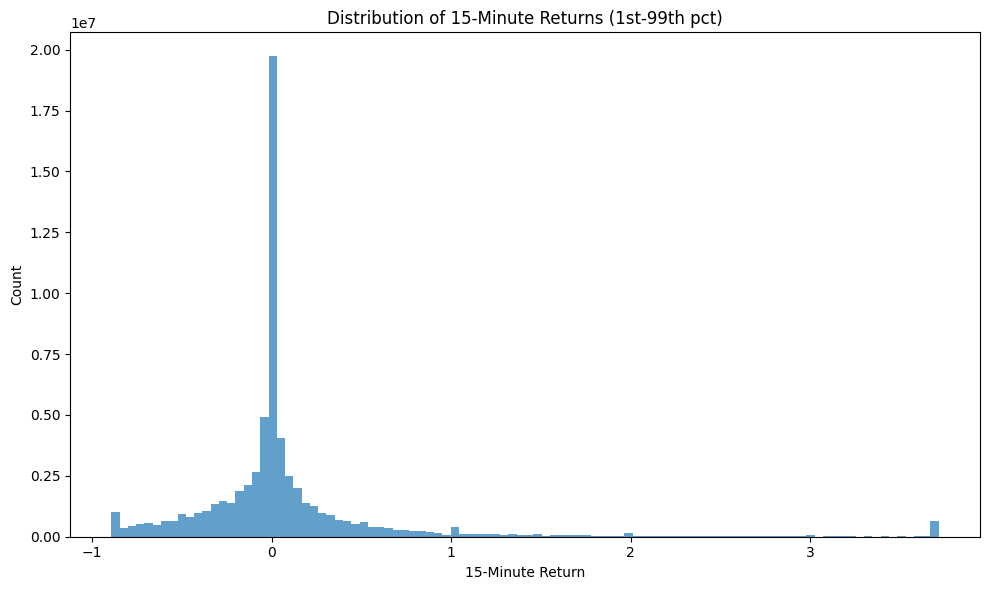

count    6.560264e+07
mean     1.396614e-01
std      1.608253e+00
min     -1.000000e+00
25%     -1.132075e-01
50%      0.000000e+00
75%      9.523810e-02
max      9.800000e+01
Name: return_15min, dtype: float64

Inf values removed: 678
Zero base prices:   6,153


In [ ]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

Kurtosis: 1147.66
Skewness: 27.69


what happens if we take away all the trades that are close to the edge cases?
i.e. price is 0-0.05 and 0.95-1

Rows after removing small base prices: 67,733,505 -> 64,041,575


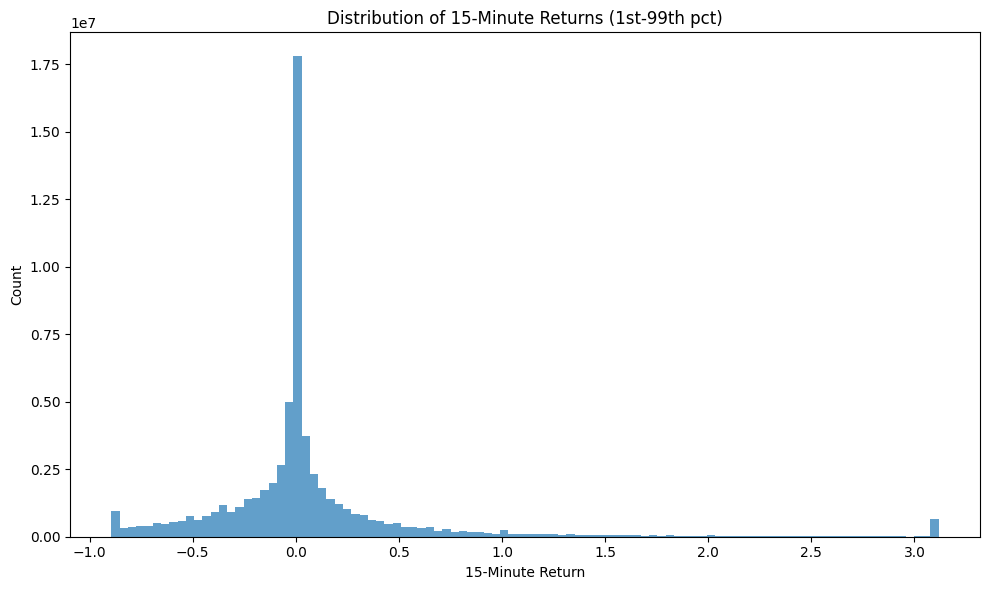

count    6.404158e+07
mean     8.973848e-02
std      8.806224e-01
min     -1.000000e+00
25%     -1.186441e-01
50%      0.000000e+00
75%      9.210526e-02
max      3.200000e+01
Name: return_15min, dtype: float64

Inf values removed: 0
Zero base prices:   0


In [ ]:
OG = len(trades)
mask = trades["yes_price_15m_ago"] >= 3
trades = trades.loc[mask].reset_index(drop=True)
del mask
print(f"Rows after removing small base prices: {OG:,} -> {len(trades):,}")

returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)  # use returns_clipped or returns
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

Kurtosis: 247.98
Skewness: 11.78


## Absolute returns

In [ ]:
trades = trades.sort_values('created_time').reset_index(drop=True)

# Drop stale column if it exists from a previous run
trades = trades.drop(columns=['yes_price_15m_ago', 'return_15min'], errors='ignore')

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = merged['yes_price'] - merged['yes_price_15m_ago']

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min
0,PRES-2024-KH,39,61,250,yes,2024-10-25 00:15:29.430123+00:00,97.50,NaN,NaN
1,PRES-2024-KH,39,61,128,yes,2024-10-25 00:15:42.873031+00:00,49.92,NaN,NaN
2,POPVOTE-24-R,36,64,27,yes,2024-10-25 00:15:44.600354+00:00,9.72,NaN,NaN
3,PRES-2024-KH,39,61,38,yes,2024-10-25 00:15:57.151717+00:00,14.82,NaN,NaN
4,POPVOTE-24-R,35,65,20,no,2024-10-25 00:16:18.724459+00:00,13.00,NaN,NaN


Non-null 15min returns: 62,256,896


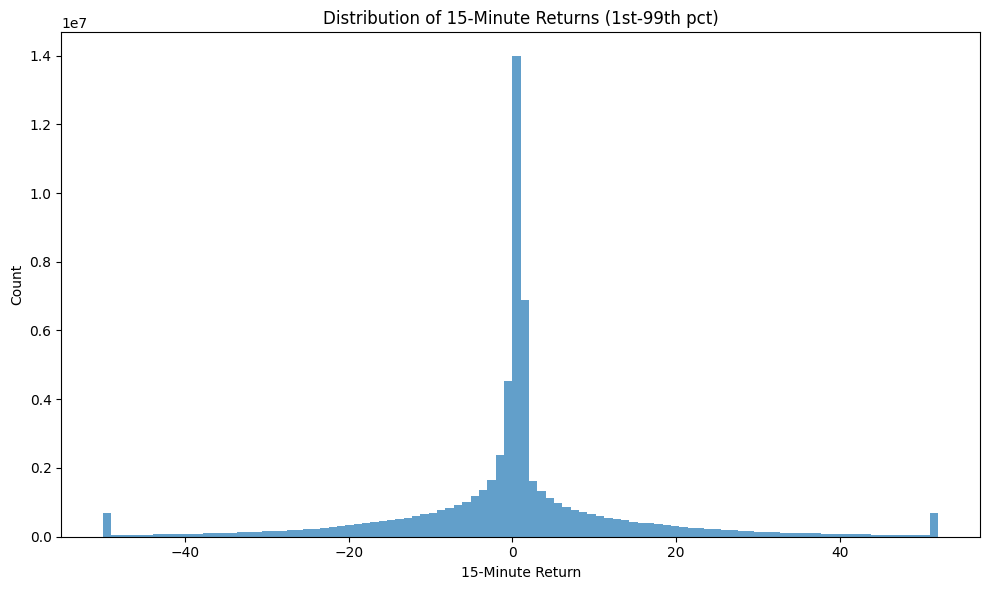

count    6.225690e+07
mean    -8.597917e-02
std      1.591070e+01
min     -9.800000e+01
25%     -4.000000e+00
50%      0.000000e+00
75%      3.000000e+00
max      9.800000e+01
Name: return_15min, dtype: float64

Inf values removed: 0
Zero base prices:   1


In [ ]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print("Kurtosis: {:.2f}".format(returns.kurtosis()))
print("Skewness: {:.2f}".format(returns.skew()))

Kurtosis: 5.80
Skewness: 0.12


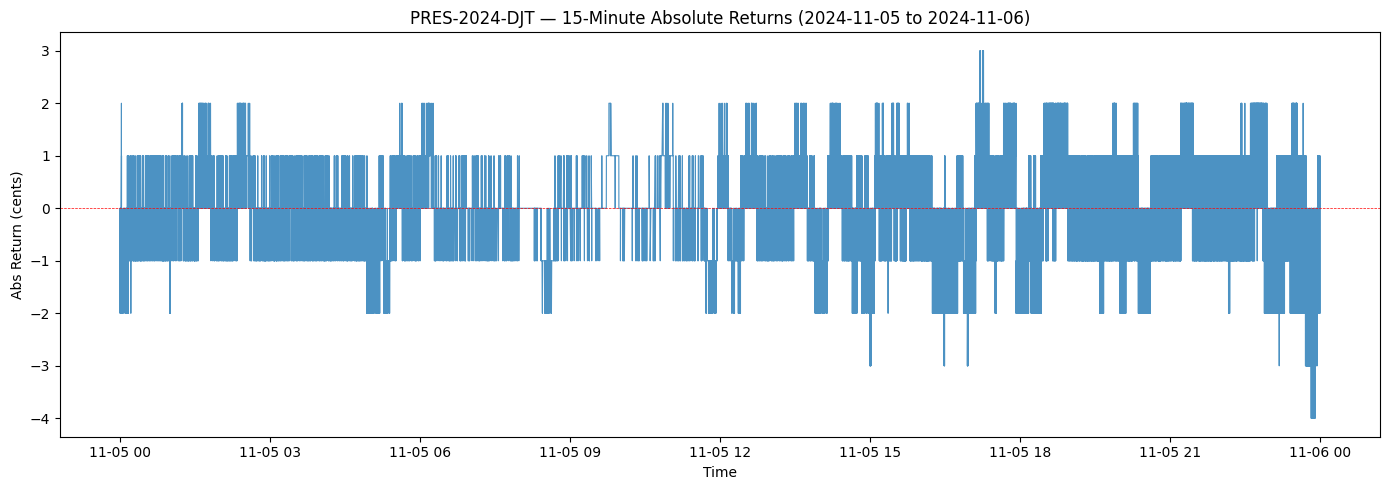

count    58938.000000
mean        -0.047202
std          0.785348
min         -4.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: return_15min, dtype: float64


In [ ]:
start_date = pd.Timestamp('2024-11-05', tz='UTC')
end_date   = pd.Timestamp('2024-11-06', tz='UTC')

djt = (
    trades[
        (trades["ticker"] == "PRES-2024-DJT") &
        (trades["created_time"] >= start_date) &
        (trades["created_time"] <= end_date)
    ]
    .sort_values("created_time")
)

plt.figure(figsize=(14, 5))
plt.plot(djt["created_time"], djt["return_15min"], lw=0.8, alpha=0.8)
plt.axhline(0, color="red", lw=0.5, linestyle="--")
plt.title(f"PRES-2024-DJT — 15-Minute Absolute Returns ({start_date.date()} to {end_date.date()})")
plt.xlabel("Time")
plt.ylabel("Abs Return (cents)")
plt.tight_layout()
plt.show()

print(djt["return_15min"].describe())

In [ ]:
returns_jump_up = returns.quantile(0.75)
returns_jump_down = returns.quantile(0.25)
print(f"75th percentile return (jump up): {returns_jump_up:.2f} cents")
print(f"25th percentile return (jump down): {returns_jump_down:.2f} cents")

75th percentile return (jump up): 3.00 cents
25th percentile return (jump down): -4.00 cents


In [ ]:
conditions = [
    trades["return_15min"] >= returns_jump_up,
    trades["return_15min"] <= returns_jump_down,
]
choices = [1, -1]
trades["y"] = np.select(conditions, choices, default=0)

In [ ]:
trades.tail()

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min,y
64041570,RECSSNBER-25,3,97,1501,yes,2025-11-25 21:44:14.198728+00:00,45.03,3.0,0.0,0
64041571,KXZELENSKYYPUTINMEET-26,18,82,39,no,2025-11-25 21:50:09.524239+00:00,31.98,18.0,0.0,0
64041572,KXZELENSKYYPUTINMEET-26,18,82,5,no,2025-11-25 21:50:09.524239+00:00,4.10,18.0,0.0,0
64041573,KXZELENSKYYPUTINMEET-26,18,82,19,no,2025-11-25 21:50:09.524239+00:00,15.58,18.0,0.0,0
64041574,SENATETX-26-R,80,20,347,no,2025-11-25 22:00:15.194245+00:00,69.40,81.0,-1.0,0


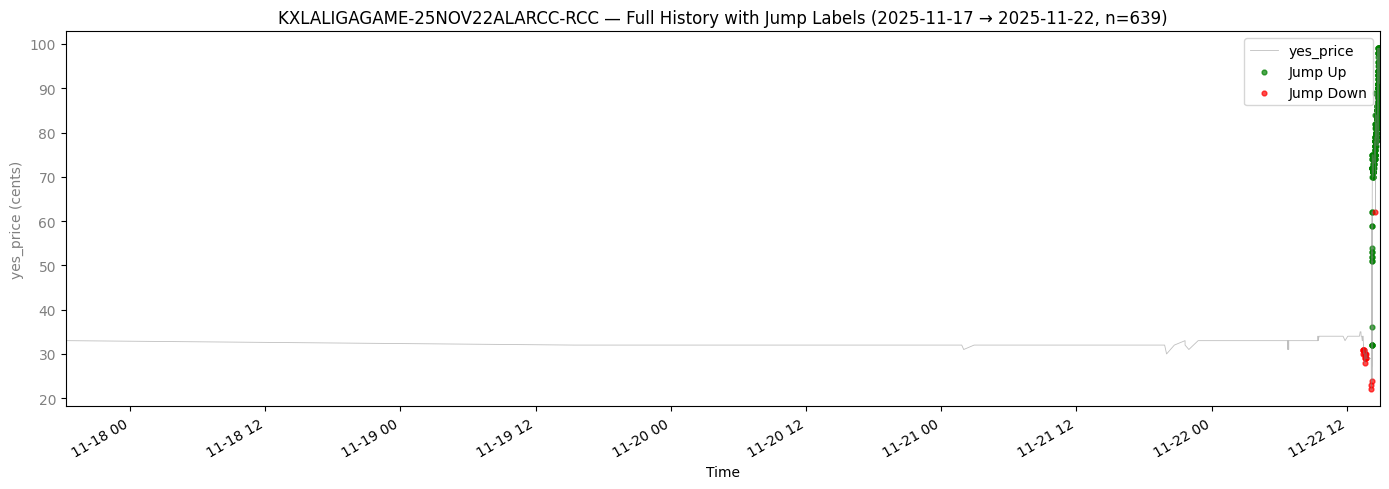

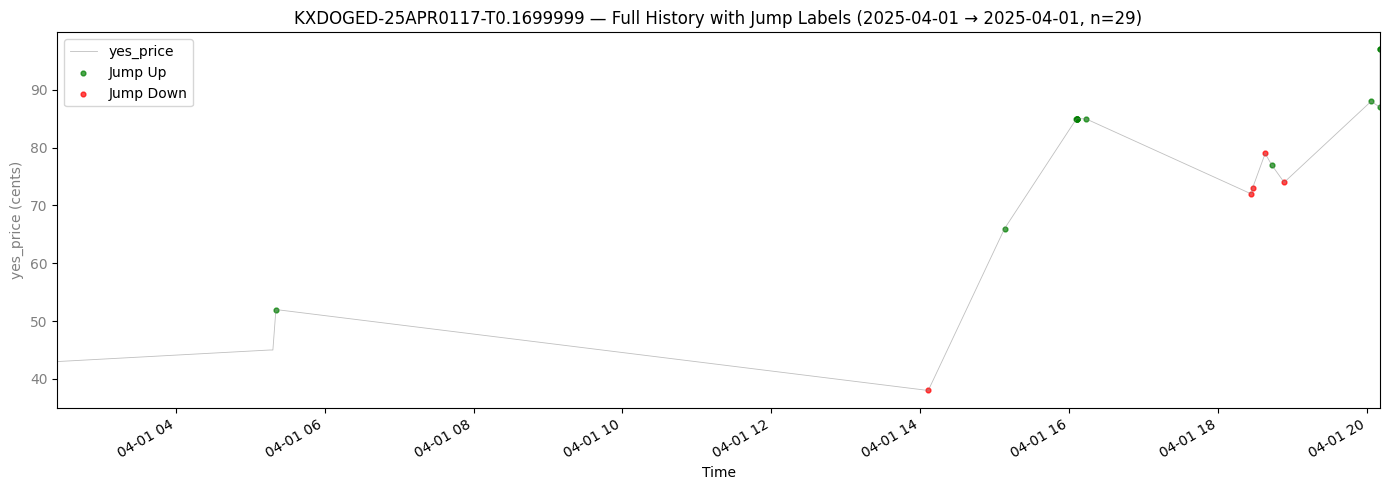

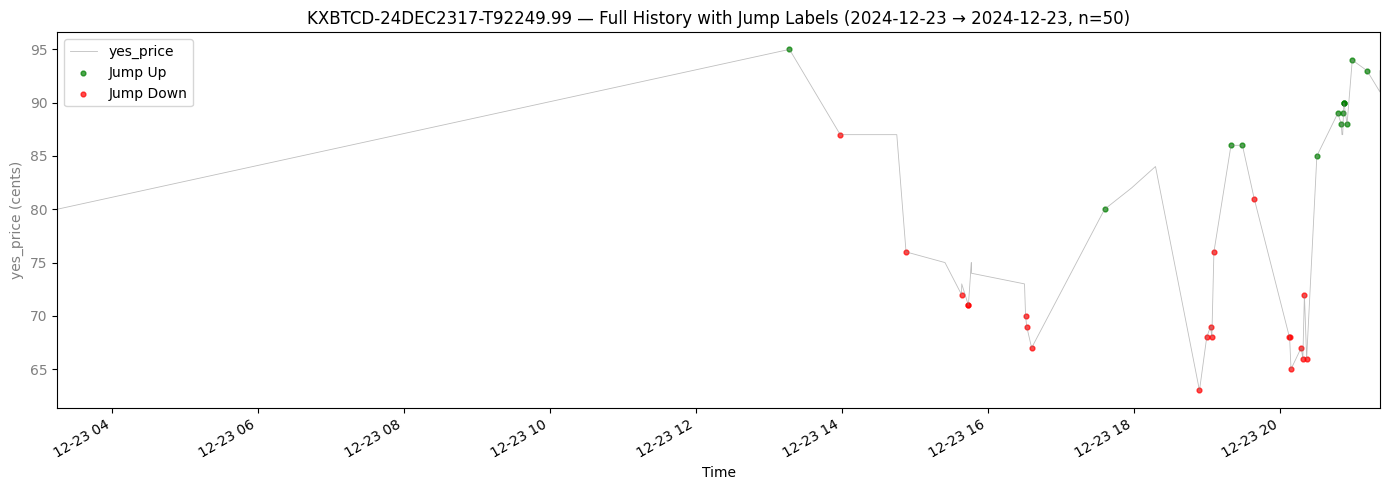

C:\Users\ablan\AppData\Local\Temp\ipykernel_11020\1205095684.py:30: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1.set_xlim(sub["created_time"].min(), sub["created_time"].max())


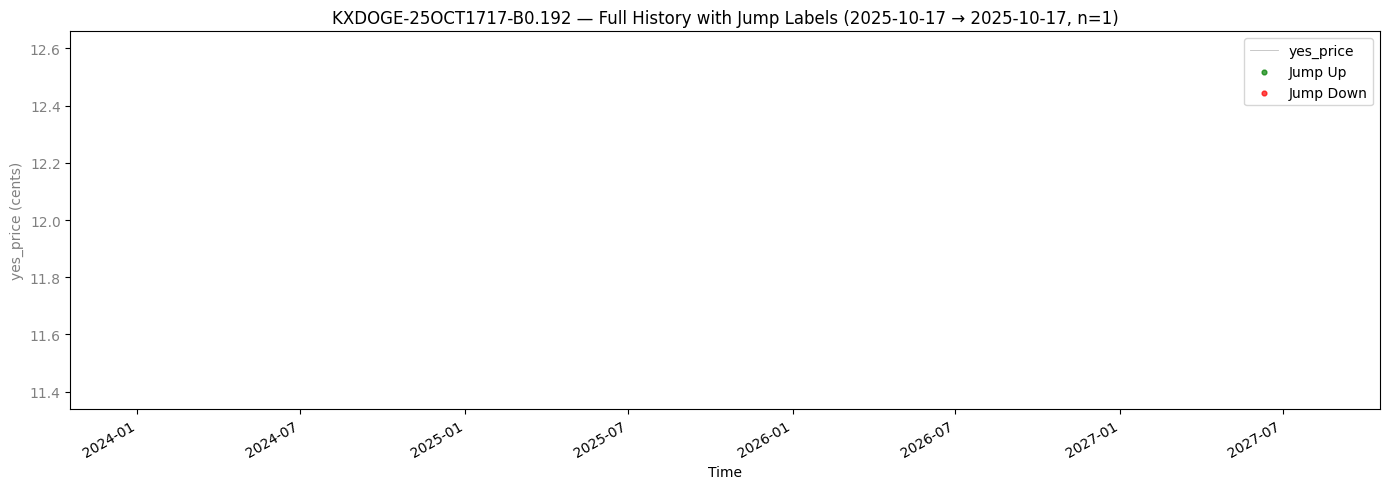

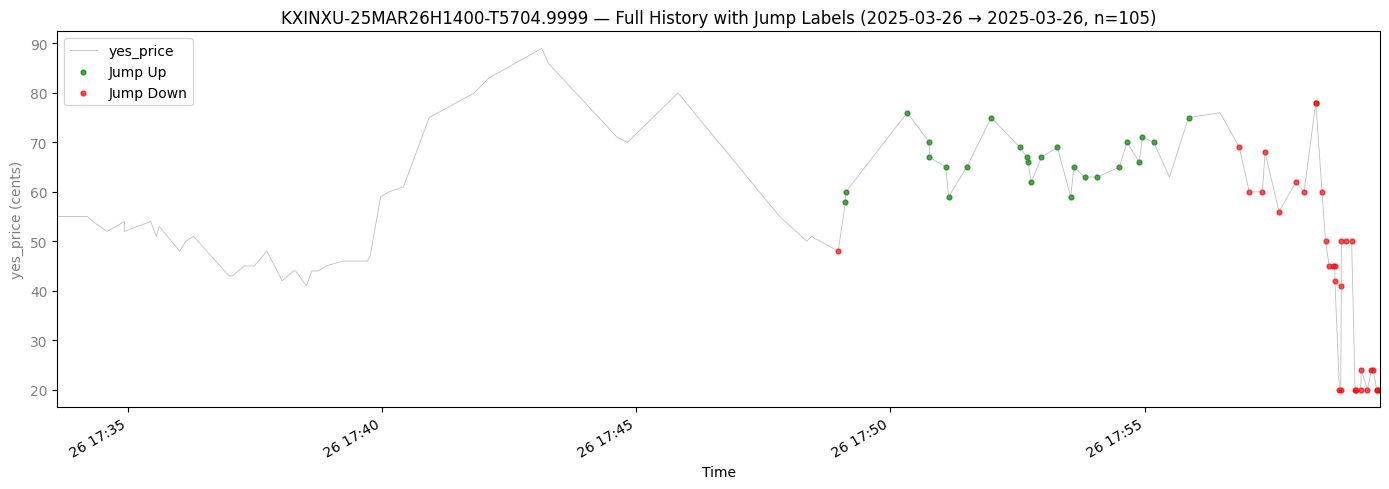

In [ ]:

np.random.seed(42)

unique_tickers = trades["ticker"].unique()
sampled_tickers = np.random.choice(unique_tickers, size=5, replace=False)

for tkr in sampled_tickers:
    sub = (
        trades[trades["ticker"] == tkr]
        .sort_values("created_time")
    )

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Price on the left axis — shows the full history
    ax1.plot(sub["created_time"], sub["yes_price"],
             lw=0.6, alpha=0.5, color="gray", label="yes_price")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("yes_price (cents)", color="gray")
    ax1.tick_params(axis="y", labelcolor="gray")

    # Overlay jump-up / jump-down markers
    jumps_up = sub[sub["y"] == 1]
    jumps_dn = sub[sub["y"] == -1]
    ax1.scatter(jumps_up["created_time"], jumps_up["yes_price"],
                s=12, color="green", alpha=0.7, label="Jump Up")
    ax1.scatter(jumps_dn["created_time"], jumps_dn["yes_price"],
                s=12, color="red", alpha=0.7, label="Jump Down")

    # Let matplotlib auto-scale to the full time range of this ticker
    ax1.set_xlim(sub["created_time"].min(), sub["created_time"].max())

    ax1.set_title(f"{tkr} — Full History with Jump Labels "
                  f"({sub['created_time'].min().date()} → {sub['created_time'].max().date()}, "
                  f"n={len(sub):,})")
    ax1.legend(loc="best")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [ ]:
trades.head()

,ticker,yes_price,no_price,count,taker_side,created_time,volume,yes_price_15m_ago,return_15min,y
0,PRES-2024-KH,39,61,250,yes,2024-10-25 00:15:29.430123+00:00,97.50,NaN,NaN,0
1,PRES-2024-KH,39,61,128,yes,2024-10-25 00:15:42.873031+00:00,49.92,NaN,NaN,0
2,POPVOTE-24-R,36,64,27,yes,2024-10-25 00:15:44.600354+00:00,9.72,NaN,NaN,0
3,PRES-2024-KH,39,61,38,yes,2024-10-25 00:15:57.151717+00:00,14.82,NaN,NaN,0
4,POPVOTE-24-R,35,65,20,no,2024-10-25 00:16:18.724459+00:00,13.00,NaN,NaN,0


In [ ]:
trades.to_parquet(os.path.join(OUTPUT_DIR, "trades_with_labels.parquet"), index=False)
print("Saved trades_with_labels.parquet")

Saved trades_with_labels.parquet


In [ ]:
len(trades)

64041575

## `trades` DataFrame — Schema & Description

A time-ordered record of individual trade executions on prediction-market contracts, enriched with a 15-minute lookback return and a discrete jump label.

### Columns

| Column | dtype | Description |
|---|---|---|
| `ticker` | `string` | Contract identifier, for example `PRES-2024-KH`, `PRES-2024-DJT`, or `POPVOTE-24-R`. Groups rows into per-market time series |
| `yes_price` | `int` (cents) | Price of the YES side of the contract at the time of the trade, in cents from 0 to 100. Interpretable as the implied probability of the event resolving YES |
| `no_price` | `int` (cents) | Price of the NO side, equal to `100 - yes_price`. Redundant with `yes_price` but included for convenience |
| `count` | `int` | Number of contracts traded in this execution |
| `taker_side` | `string` | Side of the aggressor. `"yes"` means the taker bought YES by lifting offers, while `"no"` means the taker bought NO by hitting bids. Useful as an order-flow signal |
| `created_time` | `datetime64[ns, UTC]` | Timestamp of the trade in UTC, with microsecond precision. Used as the time index for sorting and resampling |
| `volume` | `float` (dollars) | Notional trade size in dollars, computed as `count × yes_price / 100` |
| `yes_price_15m_ago` | `float` (cents) | The `yes_price` observed approximately 15 minutes earlier for the same `ticker`. `NaN` for rows within the first 15 minutes of that ticker’s history |
| `return_15min` | `float` (cents) | Price change over the prior 15 minutes, computed as `yes_price - yes_price_15m_ago`. `NaN` where a 15-minute prior price is unavailable |
| `y` | `int ∈ {-1, 0, 1}` | Jump label derived from `return_15min` quantiles across all non-`NaN` returns. `1` if `return_15min ≥ 75th` percentile, `-1` if `return_15min ≤ 25th` percentile, and `0` otherwise. Rows with `NaN` returns are assigned `0` |

### Key Properties

- **Sort order:** Rows are chronological across all tickers. Within each ticker, ordering is also time-ascending after `.sort_values("created_time")`
- **Granularity:** One row per executed trade, not aggregated bars, so inter-trade spacing is irregular
- **Label balance:** By construction, `y == 1` and `y == -1` each account for about 25% of labeled rows, while `y == 0` accounts for about 50%
- **Coverage window:** Spans from the first observed trade, for example `2024-10-25 00:15:29 UTC`, through the end of the data pull. Per-ticker ranges vary depending on listing and resolution dates

<a id="milestone-eda-features"></a>
## Milestone 3: Baseline Model

### EDA Review

As a review, here's a few things we noticed in the EDA above shaped how we built features for the baseline:

* The early part of the sample is pretty illiquid. Daily volume and the number of active tickers are both low, so we apply a calendar cut (the `first_10m_ts` style filter) before any modeling happens.

* Prices are quoted in cents via `yes_price`, and the 15-minute backward returns we looked at jump around a lot across price levels. That pushed us toward using relative returns on bars (fixed time buckets that trades get grouped into), so contracts at different price levels are comparable.

* We also looked at bid-ask spreads from the separate `markets` table during EDA, but the baseline CNN below doesn't actually use `all_markets`. It only uses features derived from trades on bars.

* Ticker names are moderately long strings, and the prefix before the first `-` cleanly identifies the sector they belong to. We use that prefix both for grouping and as the key for a sector embedding later on in the modeling portion of our project.


<a id="milestone-baseline"></a>
### Baseline Model Selection

For the baseline model, we choose a small 1D CNN with a sector embedding, defined below as `SimpleJumpCNN`.

* Input data comes from `trades_with_labels.parquet`, the same file produced during EDA with the `y` and `return_15min` columns already attached.

* We use `load_trades` to pull the data in, but running it from scratch tries to load the full history at once and blows past Colab Pro's available RAM (167 GB). To work around that, `load_trades` implements two configuration specifications, `memory.recent_days` and `memory.max_tickers`, which cap the time range and the number of distinct tickers respectively.

* Then, the pipeline itself is short. First we group trades into 1-minute bars, so instead of an irregular stream of trades we have one row per minute per ticker. For each bar we then look backward and grab the previous `lookback_bars` minautes (set at 32 in out first iteration), which gives the model a fixed-size window of recent history to work with. That window is what the CNN actually sees.

* Each minute in the window carries a handful of numbers:  the log of the volume (compressed so huge volume spikes don't dominate), the hour of the day encoded as a sine and cosine pair (so the model knows 11pm and midnight are close together), the the percentage change in price from the previous bar to the current one `ret_1`, a normalized version of the closing price, and the 15-minute EDA return `eda_ret_15m`. Those are the channels, and there's one value of each per minute. The ticker's sector isn't a channel, it goes in separately through an embedding layer that learns a little vector for each sector and adds it in.

####Labels
The default in EDA sets `y_jump` to 1 whenever the bar's last trade has `y = ±1` (a large 15-minute move) and 0 otherwise, and feeds the same 15-minute return in as `eda_ret_15m`.

The split is chronological on bar timestamps, and we report AUC-PR, AUC-ROC, and Brier score. Plots are in the next section.

What follows is a visual of the CNN operation.



cnn_conv_filter_sliding.svg

<a id="milestone-train"></a>
### Colab setup and training the baseline

We run the Colab and paths cell first, then work through Steps 1 to 10 in order: imports and config, load, bars, features, labels, metrics, dataset, model, `train_baseline_milestone`, and finally run.



In [ ]:
import os
import sys


IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive

    # Pin deps for GPU training (restart runtime if Colab prompts, then re-run from here).
    %pip install -q torch pandas numpy pyarrow scikit-learn matplotlib tqdm

    drive.mount("/content/drive")

    PROJECT_DIR = "/content/drive/MyDrive/CS1090B/project"
    os.makedirs(PROJECT_DIR, exist_ok=True)

    CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)

    DATA_ROOT = os.path.join(PROJECT_DIR, "data", "kalshi")

    import torch
    if torch.cuda.is_available():
        print(f"\nGPU ready: {torch.cuda.get_device_name(0)}")
    else:
        print("\nWARNING: No GPU detected. Go to Runtime > Change runtime type > GPU (T4/A100 if available).")

else:
    from pathlib import Path

    PROJECT_DIR = str(Path.cwd().resolve())
    CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    DATA_ROOT = os.path.join(PROJECT_DIR, "data", "kalshi")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"PROJECT_DIR: {PROJECT_DIR}")
print(f"DATA_ROOT: {DATA_ROOT}")
print(f"CHECKPOINT_DIR: {CHECKPOINT_DIR}")


Mounted at /content/drive

GPU ready: NVIDIA A100-SXM4-80GB
PROJECT_DIR: /content/drive/MyDrive/CS1090B/project
DATA_ROOT: /content/drive/MyDrive/CS1090B/project/data/kalshi
CHECKPOINT_DIR: /content/drive/MyDrive/CS1090B/project/checkpoints


### Step 1: imports and configuration

We set up PyTorch, pandas, and the sklearn metrics here. All the hyperparameters live in the `BASELINE_CFG` dictionary.

* `paths.trades_file` defaults to `trades_with_labels.parquet` so that Milestone 3 reuses the output from EDA. That file already has the `y` and `return_15min` columns and has the illiquid-period filter applied.

* `memory.recent_days` keeps only trades with `created_time` in the last N calendar days, measured relative to the latest timestamp in the file. We do this because Colab RAM usage is limited at 167GB on a high-RAM setting.  Setting this variable to `None` uses the full time range in the parquet, which is heavy.

* `memory.max_tickers` caps how many distinct tickers survive the date filter. It's a random subsample seeded by `train.seed`, and the default is 64.



In [ ]:
import copy
import gc
import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn import metrics as skm
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from tqdm.auto import tqdm

# Suppress noisy warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None

# ----- Config -----
BASELINE_CFG = {
    "paths": {
        "processed_dir": None,
        "trades_file": "trades_with_labels.parquet",
    },
    "memory": {
        "recent_days": 730,
        "max_tickers": 512,
    },
    "bars": {"freq": "1min", "price_col": "yes_price", "time_col": "created_time"},
    "labels": {
        "source": "eda",
    },
    "features": {
        "lookback_bars": 32,
        "channels": [
            "close_norm",
            "ret_1",
            "log_volume",
            "hour_sin",
            "hour_cos",
            "eda_ret_15m",
        ],
    },
    "sectors": {"max_sectors": 200, "other_label": "OTHER"},
    "train": {
        "seed": 42,
        "batch_size": 256,
        "lr": 0.001,
        "max_epochs": 12,
        "early_stopping_patience": 3,
        "device": "cuda",
    },
}

UNKNOWN = "UNKNOWN"


### Step 2: sector tag, illiquid-day filter, and loading data

* `ticker_to_sector` maps each contract to a sector by taking the prefix before the first `-`.

* `filter_from_first_high_volume_day` drops trades before the first day with very high aggregate volume (done in EDA).
* `load_trades` then reads `paths.trades_file` from `processed_dir`, applies `memory.recent_days` and `memory.max_tickers`, and returns the trades.

In [ ]:
def ticker_to_sector(ticker):
    if isinstance(ticker, str):
        return ticker.split("-", 1)[0] if "-" in ticker else UNKNOWN
    s = ticker.astype(str)
    out = s.str.split("-").str[0]
    return out.where(s.str.contains("-", regex=False), UNKNOWN)


def load_trades(cfg):
    import gc

    import pyarrow.parquet as pq

    pdir = cfg["paths"]["processed_dir"]
    path = os.path.join(pdir, cfg["paths"]["trades_file"])
    tc, pc = cfg["bars"]["time_col"], cfg["bars"]["price_col"]
    avail = set(pq.read_schema(path).names)
    want = ["ticker", tc, pc, "volume"]
    for extra in ("count", "y", "return_15min"):
        if extra in avail:
            want.append(extra)
    cols = [c for c in want if c in avail]
    rd = cfg.get("memory", {}).get("recent_days")

    if rd is not None:
        tser = pd.read_parquet(path, columns=[tc])
        tser[tc] = pd.to_datetime(tser[tc], utc=True)
        tmax = tser[tc].max()
        cutoff = tmax - pd.Timedelta(days=int(rd))
        n_in_file = len(tser)
        del tser
        gc.collect()
        try:
            trades = pd.read_parquet(path, columns=cols, filters=[(tc, ">=", cutoff)])
        except (TypeError, ValueError, OSError):
            trades = pd.read_parquet(path, columns=cols)
            trades[tc] = pd.to_datetime(trades[tc], utc=True)
            trades = trades.loc[trades[tc] >= cutoff].reset_index(drop=True)
        else:
            trades[tc] = pd.to_datetime(trades[tc], utc=True)
        print(
            f"memory.recent_days={int(rd)}: {len(trades):,} trade rows (~{n_in_file:,} in file; max ts {tmax})"
        )
        if len(trades) == 0:
            raise ValueError("memory.recent_days left zero rows; increase recent_days or check timestamps.")
    else:
        trades = pd.read_parquet(path, columns=cols)

    need = {"y", "return_15min"}
    miss = need - set(trades.columns)
    if miss:
        raise ValueError(
            f"EDA required columns {need} are missing. "
            f"Missing {miss}. Run the EDA cells that build trades_with_labels.parquet."
        )

    mx = cfg.get("memory", {}).get("max_tickers")
    if mx is not None:
        rng = np.random.RandomState(int(cfg["train"]["seed"]))
        u = trades["ticker"].unique()
        if len(u) > int(mx):
            keep = rng.choice(u, size=int(mx), replace=False)
            trades = trades[trades["ticker"].isin(keep)].reset_index(drop=True)
            print(f"memory.max_tickers: using {len(keep)} tickers (of {len(u)} in file)")
    return trades


### Step 3: calendar bars

`trades_to_bars` resamples trades into 1-minute bars for each ticker. If the trades table already carries the EDA columns `y` and `return_15min`, each bar also picks up two extras: `eda_y_last`, which is the last trade's EDA label in that minute, and `ret_15m_last`, the last trade's 15-minute return in cents. That way the CNN gets to see the EDA signals aggregated onto the bar grid.

In [ ]:
def trades_to_bars(trades, cfg):
    freq = cfg["bars"]["freq"]
    pc, tc = cfg["bars"]["price_col"], cfg["bars"]["time_col"]
    has_y = "y" in trades.columns
    has_r15 = "return_15min" in trades.columns
    has_count = "count" in trades.columns

    t = trades.copy()
    if not has_count:
        t["_n"] = np.int8(1)
    t = t.set_index(tc).sort_index()

    agg_cols = {pc: "last", "volume": "sum"}
    agg_cols["count" if has_count else "_n"] = "sum"
    if has_y:
        agg_cols["y"] = "last"
    if has_r15:
        agg_cols["return_15min"] = "last"

    bars = (
        t.groupby("ticker", sort=False)
        .resample(freq, label="right", closed="right")
        .agg(agg_cols)
        .dropna(subset=[pc])
        .reset_index()
    )

    rename_map = {tc: "ts", pc: "close",
                  ("count" if has_count else "_n"): "n_contracts"}
    if has_y:
        rename_map["y"] = "eda_y_last"
    if has_r15:
        rename_map["return_15min"] = "ret_15m_last"
    bars = bars.rename(columns=rename_map)

    bars["sector"] = ticker_to_sector(bars["ticker"])
    bars["ts"] = pd.to_datetime(bars["ts"], utc=True)
    return bars.sort_values(["ticker", "ts"]).reset_index(drop=True)


### Step 4: feature columns

`add_feature_columns` builds the channels the CNN actually sees.

The CNN receives six channels per 1-minute bar, each answering a different question about the market state at that moment. Stacked across the 32-minute lookback window, they form the `(6, 32)` matrix the convolution filters slide across.

#### `close_norm`

The bar's closing price, divided by 100 to rescale from cents into the [0, 1] range. Raw `yes_price` lives between 0 and 100 cents, which is a reasonable range but is 10 to 100 times larger than the other feature scales. Neural networks train more stably when input channels share a similar magnitude, so we compress `close` to match. This channel gives the model a sense of where the contract is priced at each step of the window, which matters because contracts at 5 cents and contracts at 80 cents exhibit very different behavior.

#### `ret_1`

The one-minute percentage return: `(close_t - close_{t-1}) / close_{t-1}`. A value of 0.02 means the price moved up 2% over the last minute, -0.05 means down 5%.

#### `log_volume`

The natural log of one plus the dollar volume traded in that minute: `log(1 + volume)`. We engineered a log function because trade volume is skewed on Kalshi. Most minutes have zero or only a few dollars of volume, but a handful of minutes have hundreds of thousands. Feeding raw volume to the model would let those outliers dominate every weight update and drown out the signal from typical minutes. The log transform compresses the tail so the model can cleanly distinguish "quiet," "active," and "huge spike" on a comparable scale. The `+1` inside exists to keep `log(0)` well-defined at 0 rather than `-∞`.

#### `hour_sin` and `hour_cos`

A cyclical encoding of the time of day. For a given fractional hour `h` (0 to 24), we compute:

- `hour_sin = sin(2π·h / 24)`
- `hour_cos = cos(2π·h / 24)`

Time of day is circular: 11pm and 1am are one hour apart, not 22 hours apart. Feeding the raw hour number would make the model treat them as distant, which is wrong. Mapping `h` to a point on the unit circle via sine and cosine fixes this: 11pm and 1am land next to each other on the circle. Two features are needed because any single one is ambiguous on its own (`sin(2)` and `sin(π - 2)` match but correspond to different times). Together, the pair uniquely identifies a position in the 24-hour cycle.

#### `eda_ret_15m`

The 15-minute return at each bar, carried over from the EDA pipeline and divided by 100 to match the scale of the other features. This is a longer-horizon momentum signal than `ret_1`: where `ret_1` asks "what happened in the last minute," `eda_ret_15m` asks "what happened in the last 15 minutes."

`return_15min` = (`price_now` - `price_15m_ago`)

So a value of 0.10 means the contract is up 10% relative to where it was 15 minutes earlier, and -0.10 means it's down 10%. Bars with no trades get a 0 placeholder after the fill step.


#### Summary

| Channel       | Horizon      | What it captures                              |
|---------------|--------------|-----------------------------------------------|
| `close_norm`  | instant      | Current price level                           |
| `ret_1`       | 1 minute     | Latest price change                           |
| `log_volume`  | 1 minute     | Trading activity                              |
| `hour_sin`    | cyclical     | Time of day (x-coordinate on 24h circle)      |
| `hour_cos`    | cyclical     | Time of day (y-coordinate on 24h circle)      |
| `eda_ret_15m` | 15 minutes   | Recent medium-horizon price move              |


In [ ]:
def add_feature_columns(bars, cfg):
    out = bars.sort_values(["ticker", "ts"]).copy()
    pc = cfg["bars"]["price_col"]
    if "close" not in out.columns and pc in out.columns:
        out = out.rename(columns={pc: "close"})
    if "close" not in out.columns:
        raise KeyError(
            "Expected a 'close' column (bar close from resampling). "
            f"Have {list(out.columns)}; price_col={pc!r}."
        )
    out["close"] = out.groupby("ticker", sort=False)["close"].ffill()
    out["close_norm"] = out["close"].astype(float) / 100.0
    ret = out.groupby("ticker", sort=False)["close"].pct_change()
    out["ret_1"] = ret.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out["log_volume"] = np.log1p(out["volume"].clip(lower=0).astype(float))
    ts = pd.to_datetime(out["ts"], utc=True)
    hour = ts.dt.hour.astype(float) + ts.dt.minute.astype(float) / 60.0
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

    if "ret_15m_last" in out.columns:
        out["eda_ret_15m"] = out["ret_15m_last"].astype(float).fillna(0.0) / 100.0
    else:
        out["eda_ret_15m"] = 0.0
    return out


def channel_names(cfg):
    ch = cfg.get("features", {}).get("channels")
    return list(ch) if ch else list(
        ("close_norm", "ret_1", "log_volume", "hour_sin", "hour_cos", "eda_ret_15m")
    )


### Step 5: labels and train/validation split

The default is `"eda"`, where `y_jump` is 1 if the bar's `eda_y_last` is either `+1` or `-1`. This is the same large-move definition as the EDA quantile labels on trades, and no sector quantile is refit. The targets are just your saved `y` values aggregated to the bar end time.

`single_time_split_mask` splits by unique bar timestamps, so train and validation are always chronological.

In [ ]:
def single_time_split_mask(bars, train_frac=0.7):
    uniq = pd.Series(bars["ts"].unique()).sort_values()
    cut = max(1, int(len(uniq) * train_frac))
    train_ts = set(uniq.iloc[:cut])
    val_ts = set(uniq.iloc[cut:])
    return bars["ts"].isin(train_ts).values, bars["ts"].isin(val_ts).values


### Step 6: metrics, scaling, and sector vocabulary

Here we pull together the evaluation and preprocessing helpers. `auc_pr`, `auc_roc`, and `brier_score` are the three metrics we use on the probabilistic predictions.

`fit_scaler` stores per-channel mean and standard deviation, computed on the training bars only to keep things causal.

`build_sector_vocab` maps sector strings to integer ids so we can feed them into `nn.Embedding`.

And `by_sector_table` summarizes performance sector by sector, which is what we use for the heterogeneity analysis later.

In [ ]:
def auc_pr(y_true, scores):
    mask = np.isfinite(y_true) & np.isfinite(scores)
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        # Return 0 instead of NaN to avoid breaking tables, but it implies no signal/data
        return 0.0
    return float(skm.average_precision_score(y_true[mask], scores[mask]))

def auc_roc(y_true, scores):
    mask = np.isfinite(y_true) & np.isfinite(scores)
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        return 0.5 # Random baseline for ROC
    return float(skm.roc_auc_score(y_true[mask], scores[mask]))

def brier_score(y_true, prob):
    mask = np.isfinite(y_true) & np.isfinite(prob)
    if mask.sum() == 0: return 1.0
    return float(np.mean((prob[mask] - y_true[mask]) ** 2))

def by_sector_table(y_true, scores, sectors, min_n=5):
    rows = []
    for s in sorted(set(sectors)):
        m = np.array([t == s for t in sectors])
        if m.sum() < min_n:
            continue
        yt, sc = y_true[m], scores[m]
        pos_n = int(np.sum(yt == 1))
        neg_n = int(np.sum(yt == 0))
        rows.append({
            "sector": s,
            "n": int(m.sum()),
            "pos_n": pos_n,
            "neg_n": neg_n,
            "pos_rate": float(np.nanmean(yt)) if len(yt) > 0 else 0,
            "auc_pr": auc_pr(yt, sc),
            "auc_roc": auc_roc(yt, sc),
        })
    return pd.DataFrame(rows)

def fit_scaler(train_df, cfg):
    scaler = {}
    for name in channel_names(cfg):
        v = train_df[name].astype(float)
        scaler[name] = (float(v.mean()), float(v.std()))
    return scaler

def build_sector_vocab(train_sectors, cfg):
    other = cfg["sectors"]["other_label"]
    max_sec = int(cfg["sectors"]["max_sectors"])
    vc = train_sectors.value_counts()
    keys = [k for k, _ in vc.head(max_sec).items()]
    if other not in keys:
        keys.append(other)
    return {k: i for i, k in enumerate(sorted(keys))}

### Step 7: `JumpBarDataset`

For each valid bar index, the dataset grabs a window of length `lookback_bars` across the feature channels, which gives us a tensor of shape `(n_channels, lookback_bars)`.

Along with that it returns the binary jump label, the sector id, and some metadata (the timestamp and ticker), which comes in handy for debugging and for computing metrics grouped by ticker or time.

In [ ]:
class JumpBarDataset(Dataset):
    def __init__(self, df, cfg, sector_to_idx, valid_mask=None, scaler=None):
        self.cfg = cfg
        self.channels = channel_names(cfg)
        self.L = int(cfg["features"]["lookback_bars"])
        self.sector_to_idx = sector_to_idx
        self.other = cfg["sectors"]["other_label"]
        df = df.sort_values(["ticker", "ts"]).reset_index(drop=True)
        self.df = df
        self.scaler = scaler or {}

        n = len(df)
        L = self.L

        # Position within each ticker's contiguous group (0, 1, 2, ...)
        ticker_codes = pd.Categorical(df["ticker"]).codes
        _, first_idx = np.unique(ticker_codes, return_index=True)
        group_starts = np.zeros(n, dtype=np.int64)
        group_starts[first_idx] = first_idx
        group_starts = np.maximum.accumulate(group_starts)
        pos_in_ticker = np.arange(n) - group_starts
        has_history = pos_in_ticker >= (L - 1)

        # Label availability
        if "y_jump" not in df.columns:
            has_label = np.zeros(n, dtype=bool)
        else:
            has_label = df["y_jump"].notna().values

        vm = np.asarray(valid_mask, dtype=bool) if valid_mask is not None else np.ones(n, dtype=bool)
        feat = df[self.channels].to_numpy(dtype=np.float32)
        any_nan_row = ~np.isfinite(feat).all(axis=1)
        self.indices = np.where(has_history & has_label & vm & ~any_nan_row)[0]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = int(self.indices[idx])
        L = self.L
        row = self.df.iloc[i]
        window = self.df.iloc[i - L + 1 : i + 1]

        x = np.zeros((len(self.channels), L), dtype=np.float32)
        for ci, ch in enumerate(self.channels):
            vals = window[ch].values.astype(np.float32)
            if ch in self.scaler:
                mu, sigma = self.scaler[ch]
                sigma = max(float(sigma), 1e-8)
                vals = (vals - mu) / sigma
            x[ci] = vals
        x = np.where(np.isfinite(x), x, 0.0)
        x = np.clip(x, -10.0, 10.0)

        sec_name = row["sector"] if "sector" in self.df.columns else self.other
        sec_id = self.sector_to_idx.get(sec_name, self.sector_to_idx.get(self.other, 0))
        sec_c = int(row["sec_c"]) if "sec_c" in self.df.columns else sec_id
        meta = {"ts": row["ts"], "ticker": row["ticker"], "sec_c": sec_c}

        return (
            torch.from_numpy(x),
            torch.tensor(sec_id, dtype=torch.long),
            torch.tensor(float(row["y_jump"]), dtype=torch.float32),
            meta,
        )


### Step 8: `SimpleJumpCNN` and batching

The model is a small 1D CNN with two conv layers, ReLU activations, and global pooling, which summarizes the temporal window into a single vector. A sector embedding then adds a learned offset for each sector on top of that.

| Stage | Shape | Notes |
|---|---|---|
| input | `(256, 6, 32)` | 256 samples, 6 channels, 32 timesteps |
| conv1 + relu | `(256, 16, 32)` | 16 learned filters, same length (padding=2) |
| conv2 + relu | `(256, 16, 32)` | patterns of patterns, receptive field ≈ 9 minutes |
| global pool | `(256, 16)` | mean over time, one number per filter |
| embedding | `(256, 8)` | separate path: sector id → learned vector |
| concat | `(256, 24)` | conv summary + sector embedding side by side |
| linear | `(256, 1)` → `(256,)` | single logit per sample, raw score |


In [ ]:
class SimpleJumpCNN(nn.Module):
    def __init__(self, n_channels, n_sectors, cfg):
        super().__init__()
        emb_dim = 8
        self.emb = nn.Embedding(n_sectors, emb_dim)
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 16, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv1d(16, 16, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(16 + emb_dim, 1)

    def forward(self, x, sector_id):
        h = self.pool(self.conv(x)).squeeze(-1)
        e = self.emb(sector_id)
        return self.head(torch.cat([h, e], dim=1)).squeeze(-1)


def _collate(batch):
    xs, secs, ys, metas = zip(*batch)
    return torch.stack(xs, 0), torch.stack(secs, 0), torch.stack(ys, 0), list(metas)


def _device(cfg):
    d = cfg["train"].get("device", "cuda")
    if d == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def _predict_loader(model, loader, device):
    model.eval()
    probs, ys, metas = [], [], []
    with torch.no_grad():
        for x, sec, y, batch_meta in loader:
            x, sec = x.to(device), sec.to(device)
            logit = model(x, sec)
            probs.append(torch.sigmoid(logit).cpu().numpy())
            ys.append(y.numpy())
            metas.extend(batch_meta)
    return np.concatenate(probs), np.concatenate(ys), metas


### Step 9: training loop and checkpoint

`train_baseline_milestone` is the function that runs everything end to end: data loading, bar construction, feature building, dataset assembly, and training itself. The trained model lands in `jump_baseline_cnn.pt`.

The loss `loss_fn = nn.BCEWithLogitsLoss()` takes raw logits directly and applies the sigmoid internally when computing binary cross-entropy. This is mathematically equivalent to applying `sigmoid` in the model and then using plain `BCELoss`, but combining the two steps is more numerically stable (it uses the log-sum-exp trick to avoid underflow on extreme logits). That's why `SimpleJumpCNN.forward` returns a logit rather than a probability.

In [ ]:
def train_baseline_milestone(cfg, train_frac=0.7, use_cache=True):
    random.seed(int(cfg["train"]["seed"]))
    np.random.seed(int(cfg["train"]["seed"]))
    torch.manual_seed(int(cfg["train"]["seed"]))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(cfg["train"]["seed"]))

    cfg = copy.deepcopy(cfg)
    cfg["paths"]["processed_dir"] = os.path.join(DATA_ROOT, "processed")

    rd = cfg["memory"]["recent_days"]
    mt = cfg["memory"]["max_tickers"]
    cache_path = os.path.join(
        cfg["paths"]["processed_dir"],
        f"bars_cache_{rd}d_{mt}tkr.parquet"
    )

    ckpt_path = os.path.join(CHECKPOINT_DIR, "jump_baseline_cnn.pt")
    if use_cache and os.path.exists(ckpt_path):
        print(f"Loading checkpoint from {ckpt_path}, skipping training.")
        bars = pd.read_parquet(cache_path)
        bars["ts"] = pd.to_datetime(bars["ts"], utc=True)
        yl = bars["eda_y_last"].fillna(0.0).astype(float)
        bars["y_jump"] = (yl.abs() == 1.0).astype(np.float32)
        other = cfg["sectors"]["other_label"]
        _, val_mask = single_time_split_mask(bars, train_frac=train_frac)
        tm = ~np.asarray(val_mask, dtype=bool)
        vm = np.asarray(val_mask, dtype=bool)
        df = bars
        vocab = build_sector_vocab(df.loc[tm, "sector"], cfg)
        scaler = fit_scaler(df.loc[tm], cfg)
        df["sec_c"] = df["sector"].map(vocab).fillna(vocab.get(other, 0))
        val_ds = JumpBarDataset(df, cfg, vocab, valid_mask=vm, scaler=scaler)
        device = _device(cfg)
        ckpt = torch.load(ckpt_path, map_location=device)
        model = SimpleJumpCNN(len(channel_names(cfg)), len(vocab), cfg).to(device)
        model.load_state_dict(ckpt["model_state"])
        val_loader = DataLoader(val_ds, batch_size=int(cfg["train"]["batch_size"]), shuffle=False, collate_fn=_collate)
        pv, yv, mv = _predict_loader(model, val_loader, device)
        val_sector_names = [m["sec_c"] for m in mv]
        return {"skipped": False, "auc_pr": auc_pr(yv, pv), "auc_roc": auc_roc(yv, pv), "brier": brier_score(yv, pv), "by_sector": by_sector_table(yv, pv, val_sector_names), "y_val": yv, "p_val": pv, "bars_df": df}

    if use_cache and os.path.exists(cache_path):
        print(f"Loading precomputed bars from cache: {cache_path}")
        bars = pd.read_parquet(cache_path)
        bars["ts"] = pd.to_datetime(bars["ts"], utc=True)
    else:
        print("Calculating bars from trades... this may take a while.")
        trades = load_trades(cfg)
        bars = trades_to_bars(trades, cfg)
        del trades
        gc.collect()
        bars = add_feature_columns(bars, cfg)
        bars = bars.sort_values(["ticker", "ts"]).reset_index(drop=True)
        bars.to_parquet(cache_path, index=False)
        print(f"Saved bars cache to {cache_path}")

    other = cfg["sectors"]["other_label"]

    yl = bars["eda_y_last"].fillna(0.0).astype(float)
    bars["y_jump"] = (yl.abs() == 1.0).astype(np.float32)
    print(f"Unique timestamps: {bars['ts'].nunique()}")
    train_mask, val_mask = single_time_split_mask(bars, train_frac=train_frac)
    df = bars

    tm = np.asarray(train_mask, dtype=bool)
    vm = np.asarray(val_mask, dtype=bool)

    scaler = fit_scaler(df.loc[tm], cfg)
    vocab = build_sector_vocab(df.loc[tm, "sector"], cfg)
    inv_vocab = {v: k for k, v in vocab.items()}
    df["sec_c"] = df["sector"].map(vocab).fillna(vocab.get(other, 0))

    train_ds = JumpBarDataset(df, cfg, vocab, valid_mask=tm, scaler=scaler)
    val_ds = JumpBarDataset(df, cfg, vocab, valid_mask=vm, scaler=scaler)

    print(f"Training samples: {len(train_ds)}, Validation samples: {len(val_ds)}")

    device = _device(cfg)
    train_loader = DataLoader(train_ds, batch_size=int(cfg["train"]["batch_size"]), shuffle=True, collate_fn=_collate)
    val_loader = DataLoader(val_ds, batch_size=int(cfg["train"]["batch_size"]), shuffle=False, collate_fn=_collate)

    model = SimpleJumpCNN(len(channel_names(cfg)), len(vocab), cfg).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=float(cfg["train"]["lr"]))
    loss_fn = nn.BCEWithLogitsLoss()

    best_ap, bad, max_ep = -1.0, 0, int(cfg["train"]["max_epochs"])

    for ep in range(max_ep):
        model.train()
        total_loss = 0
        for x, sec, y, _ in train_loader:
            x, sec, y = x.to(device), sec.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(x, sec), y)
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"Epoch {ep+1}: encountered NaN/Inf loss, skipping batch")
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            total_loss += loss.item()

        pv, yv, mv = _predict_loader(model, val_loader, device)
        ap = auc_pr(yv, pv)
        print(f"Epoch {ep+1}/{max_ep} - Loss: {total_loss/len(train_loader):.4f} - Val AUC-PR: {ap:.4f}")

        if ap > best_ap:
            best_ap, bad = ap, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= int(cfg["train"]["early_stopping_patience"]): break

    model.load_state_dict(best_state)
    torch.save({"model_state": best_state, "label_source": cfg["labels"]["source"]}, ckpt_path)

    pv, yv, mv = _predict_loader(model, val_loader, device)
    val_sector_names = [m['sec_c'] for m in mv]
    return {"skipped": False, "auc_pr": auc_pr(yv, pv), "auc_roc": auc_roc(yv, pv), "brier": brier_score(yv, pv), "by_sector": by_sector_table(yv, pv, val_sector_names), "y_val": yv, "p_val": pv, "bars_df": df}

### Milestone 3 Step 10: run and display results

This cell calls `train_baseline_milestone` with a 70/30 time split on timestamps, prints the headline metrics, and renders the by-sector table when IPython is available. If the run gets skipped, usually because there aren't enough samples after filtering, the returned dict explains why.

In [ ]:
baseline = train_baseline_milestone(BASELINE_CFG, train_frac=0.7)
if not baseline.get("skipped"):
    print("AUC-PR:", baseline["auc_pr"], "AUC-ROC:", baseline["auc_roc"], "Brier:", baseline["brier"])
    bars = baseline.get("bars_df")
    try:
        from IPython.display import display
        display(baseline["by_sector"])
    except Exception:
        print(baseline["by_sector"])
else:
    print("Skipped:", baseline)

Calculating bars from trades... this may take a while.
memory.recent_days=730: 64,041,575 trade rows (~64,041,575 in file; max ts 2025-11-25 22:00:15.194245+00:00)
memory.max_tickers: using 512 tickers (of 267751 in file)
Saved bars cache to /content/drive/MyDrive/CS1090B/project/data/kalshi/processed/bars_cache_730d_512tkr.parquet
Unique timestamps: 30855
Training samples: 16366, Validation samples: 8621
Epoch 1/12 - Loss: 0.5781 - Val AUC-PR: 0.4092
Epoch 2/12 - Loss: 0.4384 - Val AUC-PR: 0.5604
Epoch 3/12 - Loss: 0.3951 - Val AUC-PR: 0.6098
Epoch 4/12 - Loss: 0.3740 - Val AUC-PR: 0.6279
Epoch 5/12 - Loss: 0.3629 - Val AUC-PR: 0.6378
Epoch 6/12 - Loss: 0.3541 - Val AUC-PR: 0.6465
Epoch 7/12 - Loss: 0.3467 - Val AUC-PR: 0.6625
Epoch 8/12 - Loss: 0.3387 - Val AUC-PR: 0.6816
Epoch 9/12 - Loss: 0.3327 - Val AUC-PR: 0.6811
Epoch 10/12 - Loss: 0.3261 - Val AUC-PR: 0.6756
Epoch 11/12 - Loss: 0.3211 - Val AUC-PR: 0.6773
AUC-PR: 0.6816493791209737 AUC-ROC: 0.8807036797527137 Brier: 0.10541284

,sector,n,pos_n,neg_n,pos_rate,auc_pr,auc_roc
0,3,167,92,75,0.550898,0.756614,0.804203
1,7,9,9,0,1.000000,0.000000,0.500000
2,17,20,1,19,0.050000,0.050000,0.000000
3,19,1162,58,1104,0.049914,0.610969,0.980416
4,29,20,9,11,0.450000,0.459308,0.454545
5,30,78,19,59,0.243590,0.319874,0.545941
6,34,80,11,69,0.137500,0.486584,0.770751
7,39,143,46,97,0.321678,0.915749,0.965262
8,43,27,3,24,0.111111,0.527778,0.833333
9,58,71,34,37,0.478873,0.574072,0.546900


In [ ]:
if 'baseline' in locals() and 'bars' in locals():
    print("--- Regenerating Sector Table with Human-Readable Names ---")

    # 1. Recreate the mapping from the existing 'bars' dataframe
    # 'sec_c' is the ID, 'sector' is the name
    mapping = bars[['sector', 'sec_c']].drop_duplicates()
    inv_vocab = dict(zip(mapping['sec_c'], mapping['sector']))

    # 2. Get the validation metadata from the last run
    # baseline['p_val'] and baseline['y_val'] contain the scores/labels
    # We need to align them with the sector names

    # The train_baseline_milestone returned the validation probabilities in order.
    # We'll use the validation mask to pull the corresponding sector names from 'bars'
    _, val_mask = single_time_split_mask(bars, train_frac=0.7)
    # Note: Dataset logic shifts by lookback, so we use the metadata stored in 'baseline' if available
    # Or simply map the IDs if they were strings in the output table

    readable_table = baseline['by_sector'].copy()
    # Convert the 'sector' column (currently IDs) to actual names
    # IDs in the table might be strings like '30.0', so we handle that conversion
    readable_table['sector_name'] = readable_table['sector'].apply(lambda x: inv_vocab.get(float(x), 'UNKNOWN'))

    # Reorder columns for better view
    cols = ['sector_name', 'sector'] + [c for c in readable_table.columns if c not in ['sector_name', 'sector']]
    display(readable_table[cols].sort_values('auc_pr', ascending=False))
else:
    print("Data not found. Please run the training cell once to initialize variables.")

--- Regenerating Sector Table with Human-Readable Names ---


,sector_name,sector,n,pos_n,neg_n,pos_rate,auc_pr,auc_roc
12,KXNFLANYTD,63,10,8,2,0.800000,1.000000,1.000000
7,KXLALIGAGAME,39,143,46,97,0.321678,0.915749,0.965262
14,KXNFLSPREAD,67,590,194,396,0.328814,0.900031,0.956941
13,KXNFLGAME,65,2037,153,1884,0.075110,0.869063,0.990775
10,KXNCAAFGAME,59,545,132,413,0.242202,0.818860,0.952454
0,KXATPMATCH,3,167,92,75,0.550898,0.756614,0.804203
23,KXXRPD,103,2667,747,1920,0.280090,0.685206,0.840289
11,KXNCAAFSPREAD,60,13,5,8,0.384615,0.623590,0.500000
3,KXELECTIONMOVNJGOV,19,1162,58,1104,0.049914,0.610969,0.980416
21,KXVACCINERECS,96,5,3,2,0.600000,0.588889,0.333333


### Save Processed Bars to Cache
To avoid waiting ~50 minutes for the `trades_to_bars` and `add_feature_columns` logic next time, we'll save the result to a Parquet file.

In [ ]:
if 'readable_table' in locals():
    print(f"Total unique sectors in validation results: {len(readable_table)}")
    # Display the full table sorted by number of samples
    display(readable_table.sort_values('n', ascending=False))
else:
    print("Results table not found. Please run the training or patch cells.")

Total unique sectors in validation results: 24


,sector,n,pos_n,neg_n,pos_rate,auc_pr,auc_roc,sector_name
23,103,2667,747,1920,0.280090,0.685206,0.840289,KXXRPD
13,65,2037,153,1884,0.075110,0.869063,0.990775,KXNFLGAME
3,19,1162,58,1104,0.049914,0.610969,0.980416,KXELECTIONMOVNJGOV
18,82,786,7,779,0.008906,0.008882,0.437007,KXSONGSONCHARTTSWIFT2
14,67,590,194,396,0.328814,0.900031,0.956941,KXNFLSPREAD
10,59,545,132,413,0.242202,0.818860,0.952454,KXNCAAFGAME
0,3,167,92,75,0.550898,0.756614,0.804203,KXATPMATCH
7,39,143,46,97,0.321678,0.915749,0.965262,KXLALIGAGAME
6,34,80,11,69,0.137500,0.486584,0.770751,KXHIGHNY
5,30,78,19,59,0.243590,0.319874,0.545941,KXHIGHDEN


In [ ]:
try:
    cache_path = os.path.join(DATA_ROOT, 'processed', 'bars_cache_730d_512tkr.parquet')
    # Note: We use the local 'bars' variable created during the last run if available
    # In a real pipeline, you would pull this out of the train function
    if 'bars' in locals():
        bars.to_parquet(cache_path, index=False)
        print(f"Successfully cached processed bars to: {cache_path}")
    else:
        print("Variable 'bars' not found in local scope. Ensure the training run completed or modify the script to return the bars dataframe.")
except Exception as e:
    print(f"Failed to save cache: {e}")

Successfully cached processed bars to: /content/drive/MyDrive/CS1090B/project/data/kalshi/processed/bars_cache_730d_512tkr.parquet


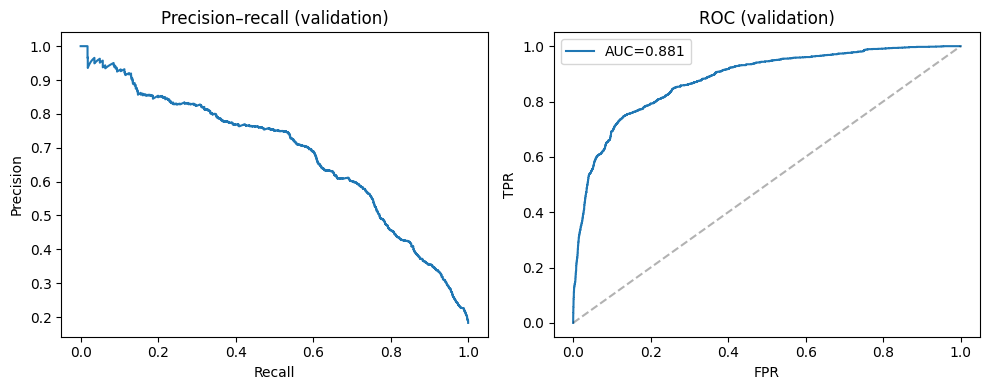

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc

if baseline.get("skipped"):
    print("Skipped:", baseline.get("reason"))
else:
    yv = baseline["y_val"]
    pv = baseline["p_val"]
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    pr_p, pr_r, _ = precision_recall_curve(yv, pv)
    ax[0].plot(pr_r, pr_p)
    ax[0].set_title("Precision–recall (validation)")
    ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
    fpr, tpr, _ = roc_curve(yv, pv)
    ax[1].plot(fpr, tpr, label=f"AUC={auc(fpr, tpr):.3f}")
    ax[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax[1].set_title("ROC (validation)")
    ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
    ax[1].legend()
    plt.tight_layout()
    plt.show()


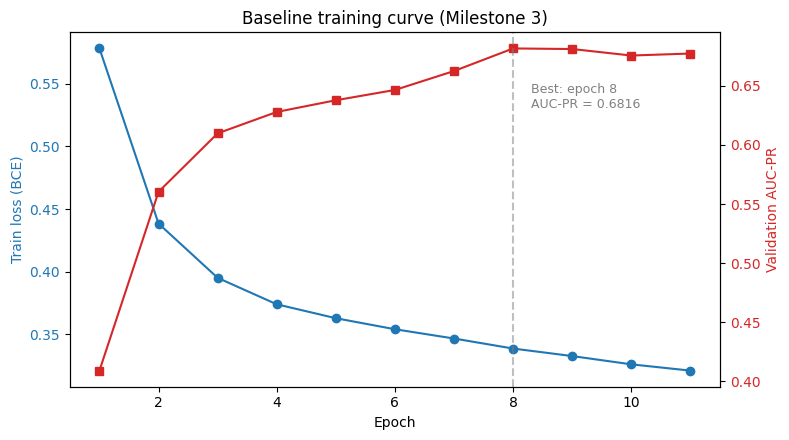

In [ ]:
import matplotlib.pyplot as plt

epochs     = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
train_loss = [0.5781, 0.4384, 0.3951, 0.3740, 0.3629, 0.3541, 0.3467, 0.3387, 0.3327, 0.3261, 0.3211]
val_aucpr  = [0.4092, 0.5604, 0.6098, 0.6279, 0.6378, 0.6465, 0.6625, 0.6816, 0.6811, 0.6756, 0.6773]

fig, ax1 = plt.subplots(figsize=(8, 4.5))

color_loss = "#1f77b4"
ax1.plot(epochs, train_loss, color=color_loss, marker='o', label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss (BCE)', color=color_loss)
ax1.tick_params(axis='y', labelcolor=color_loss)

ax2 = ax1.twinx()
color_auc = "#d62728"
ax2.plot(epochs, val_aucpr, color=color_auc, marker='s', label='Val AUC-PR')
ax2.set_ylabel('Validation AUC-PR', color=color_auc)
ax2.tick_params(axis='y', labelcolor=color_auc)

# Mark the best epoch
best_epoch = epochs[val_aucpr.index(max(val_aucpr))]
ax2.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
ax2.annotate(f'Best: epoch {best_epoch}\nAUC-PR = {max(val_aucpr):.4f}',
             xy=(best_epoch, max(val_aucpr)),
             xytext=(best_epoch + 0.3, max(val_aucpr) - 0.05),
             fontsize=9, color='gray')

plt.title('Baseline training curve (Milestone 3)')
fig.tight_layout()
plt.show()

### Interpreting the results

#### Performance summary

The validation AUC-PR of around 0.682 shows the model hitting high precision and recall together, well above what a random baseline would manage. That's a decent signal that the 1D CNN is picking up on the temporal patterns we flagged as jumps during the EDA.

The ROC of 0.881 highlights strong separation between jump and non-jump bars.
